In [1]:
import pandas as pd
import numpy as np
import shap
import joblib
import matplotlib.pyplot as plt
from tensorflow import keras

import warnings
warnings.filterwarnings('ignore')


In [2]:
# Load the trained ANN model
model = keras.models.load_model("../models/best_ann_model.keras")
print("Model loaded successfully!")

Model loaded successfully!


In [3]:
# Load preprocessed data
X_train = joblib.load("../models/X_train_processed.pkl")
X_test = joblib.load("../models/X_test_processed.pkl")
y_test = joblib.load("../models/y_test_processed.pkl")

In [4]:
print(f"Training data shape: {X_train.shape}")
print(f"Test data shape: {X_test.shape}")

Training data shape: (12740, 17)
Test data shape: (2000, 17)


In [5]:
# Define prediction function for SHAP
def model_predict(x):
    """Wrapper function for model prediction"""
    if isinstance(x, pd.DataFrame):
        x = x.values
    return model.predict(x, verbose=0).flatten()

In [6]:
# Create a background dataset for SHAP (use a subset for efficiency)
background_size = min(100, X_train.shape[0])
background = X_train[:background_size]

In [7]:
print(f"Using {background_size} samples for SHAP background")

Using 100 samples for SHAP background


In [8]:
# Create SHAP explainer
# Note: This may take a few minutes to run
print("\nCreating SHAP explainer (this may take a few minutes)...")
explainer = shap.KernelExplainer(model_predict, background)



Creating SHAP explainer (this may take a few minutes)...


In [9]:
# Calculate SHAP values for a subset of test data
test_samples = min(50, X_test.shape[0])
print(f"\nCalculating SHAP values for {test_samples} test samples...")
shap_values = explainer.shap_values(X_test[:test_samples], nsamples=100)

print(f"SHAP values shape: {shap_values.shape}")


Calculating SHAP values for 50 test samples...


  0%|          | 0/50 [00:00<?, ?it/s]

SHAP values shape: (50, 17)


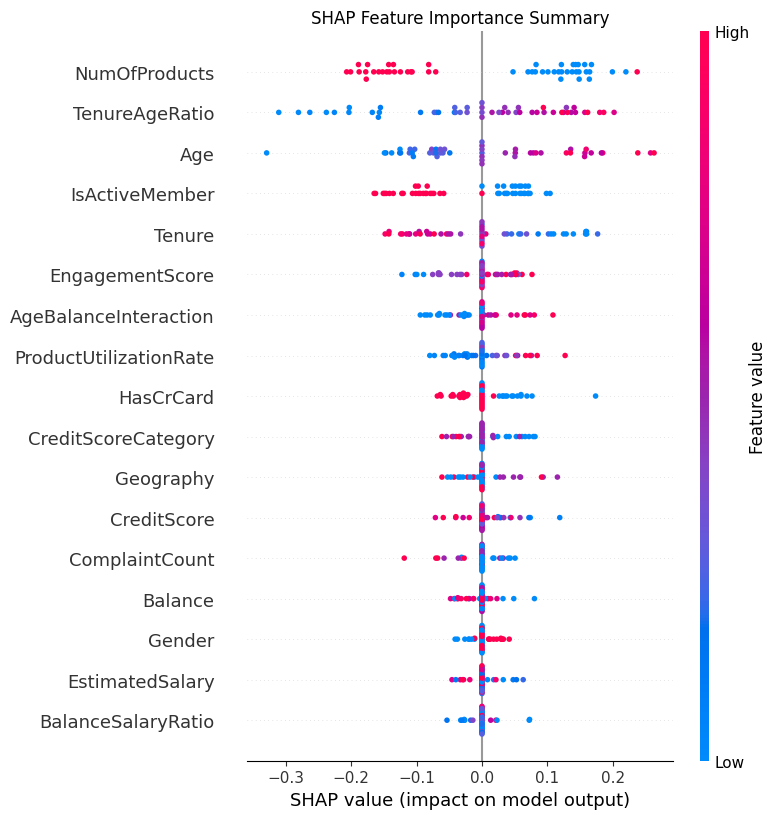

In [10]:
# Summary plot - Feature importance
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test[:test_samples], show=False)
plt.title('SHAP Feature Importance Summary')
plt.tight_layout()
plt.show()

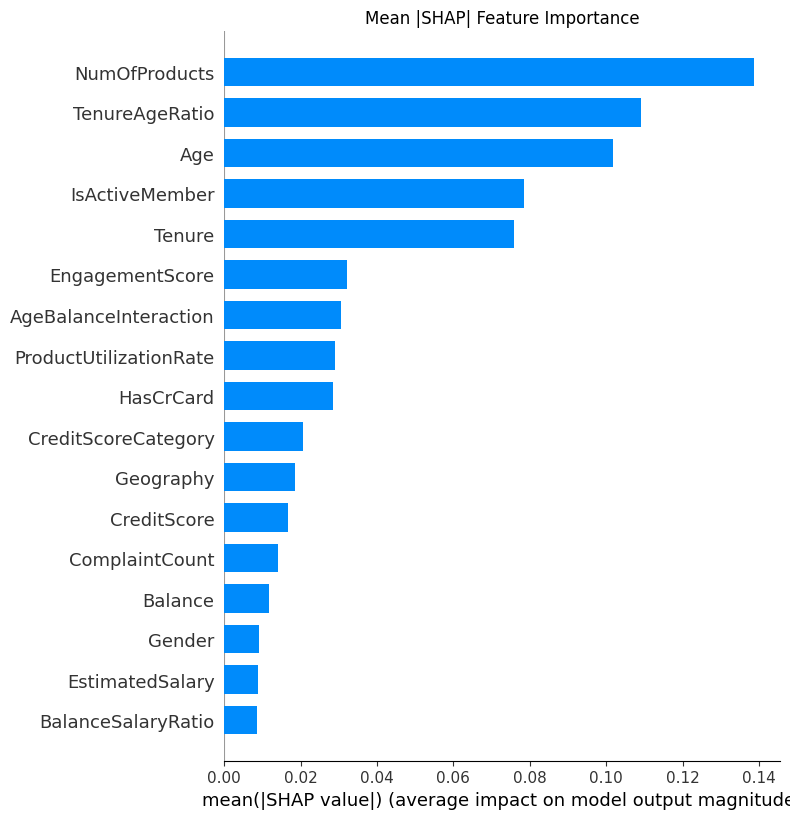

In [11]:
# Bar plot - Mean absolute SHAP values
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test[:test_samples], plot_type="bar", show=False)
plt.title('Mean |SHAP| Feature Importance')
plt.tight_layout()
plt.show()

In [12]:
# Calculate feature importance
feature_importance = pd.DataFrame({
    'feature': X_test.columns,
    'importance': np.abs(shap_values).mean(axis=0)
}).sort_values('importance', ascending=False)

print("\nFeature Importance Ranking:")
print("=" * 50)
print(feature_importance.to_string(index=False))



Feature Importance Ranking:
               feature  importance
         NumOfProducts    0.138606
        TenureAgeRatio    0.109108
                   Age    0.101802
        IsActiveMember    0.078485
                Tenure    0.075893
       EngagementScore    0.032215
 AgeBalanceInteraction    0.030500
ProductUtilizationRate    0.028970
             HasCrCard    0.028330
   CreditScoreCategory    0.020562
             Geography    0.018473
           CreditScore    0.016796
        ComplaintCount    0.014016
               Balance    0.011601
                Gender    0.009024
       EstimatedSalary    0.008785
    BalanceSalaryRatio    0.008636



SINGLE PREDICTION EXPLANATION
Analyzing sample index: 10
Actual value: Churned
Predicted probability: 0.6534


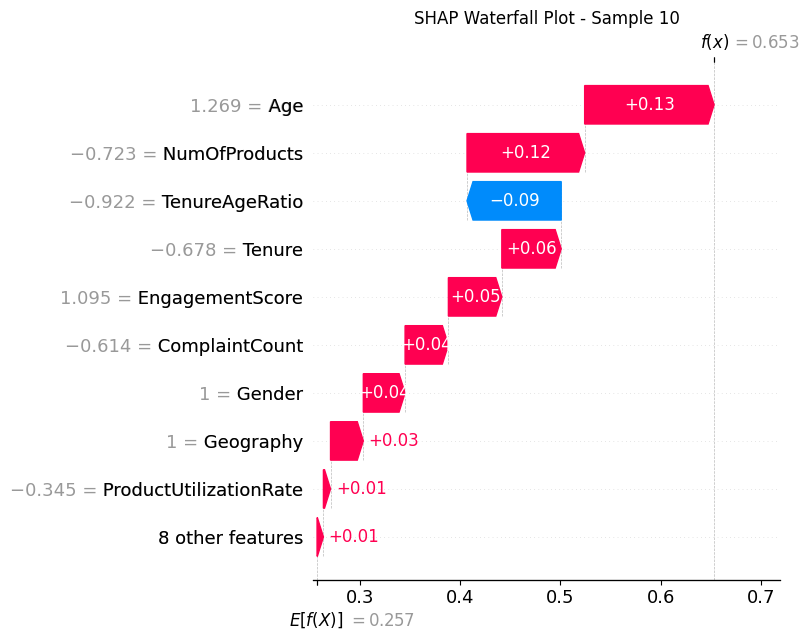

In [13]:
# Create a waterfall plot for a specific prediction
# Choose a correctly predicted churned customer
churned_indices = np.where(y_test[:test_samples] == 1)[0]
if len(churned_indices) > 0:
    sample_idx = churned_indices[0]
    
    print(f"\n" + "=" * 60)
    print("SINGLE PREDICTION EXPLANATION")
    print("=" * 60)
    print(f"Analyzing sample index: {sample_idx}")
    print(f"Actual value: {'Churned' if y_test.iloc[sample_idx] == 1 else 'Not Churned'}")
    print(f"Predicted probability: {model_predict(X_test.iloc[sample_idx: sample_idx+1])[0]:.4f}")
    
    # Create waterfall plot
    plt.figure(figsize=(12, 6))
    shap.waterfall_plot(
        shap.Explanation(
            values=shap_values[sample_idx],
            base_values=explainer.expected_value,
            data=X_test.iloc[sample_idx].values,
            feature_names=X_test.columns.tolist()
        ),
        show=False
    )
    plt.title(f'SHAP Waterfall Plot - Sample {sample_idx}')
    plt.tight_layout()
    plt.show()


Generating dependence plots for top features: ['NumOfProducts', 'TenureAgeRatio', 'Age']


<Figure size 1000x600 with 0 Axes>

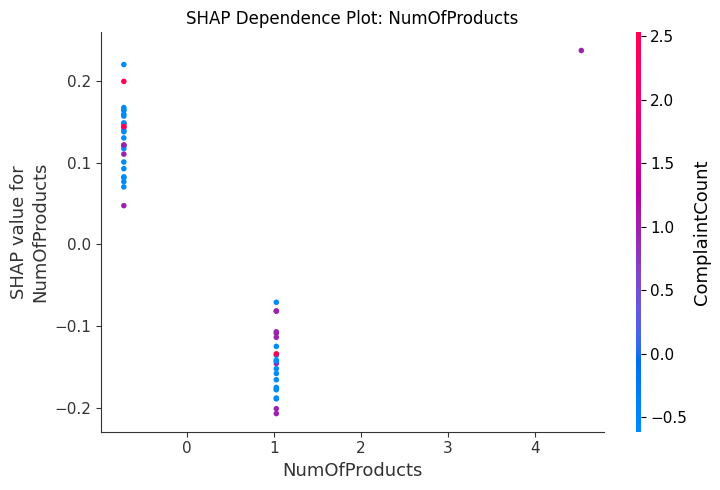

<Figure size 1000x600 with 0 Axes>

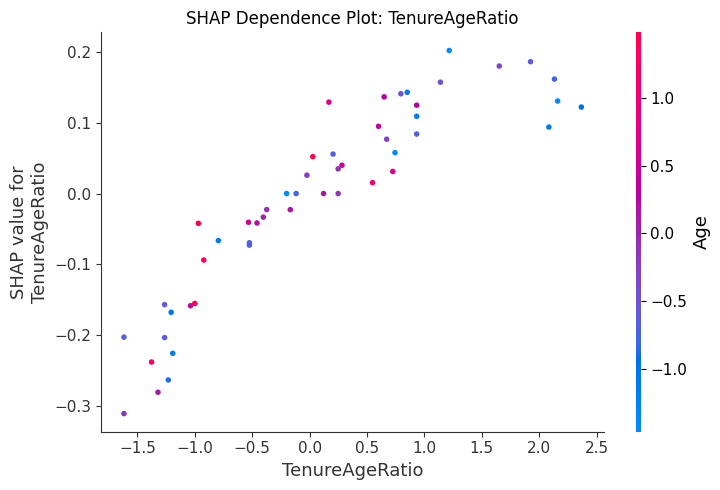

<Figure size 1000x600 with 0 Axes>

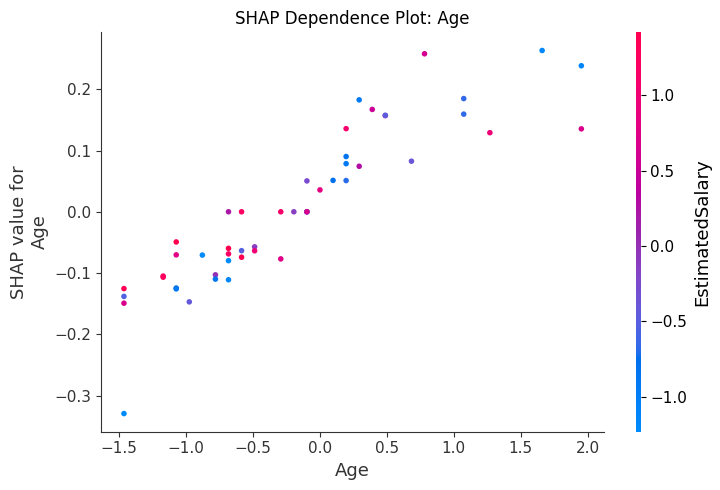

In [14]:
# Create a dependence plot for top features
top_features = feature_importance.head(3)['feature'].tolist()
print(f"\nGenerating dependence plots for top features: {top_features}")

for feature in top_features:
    plt.figure(figsize=(10, 6))
    shap.dependence_plot(
        feature, 
        shap_values, 
        X_test[:test_samples],
        show=False
    )
    plt.title(f'SHAP Dependence Plot: {feature}')
    plt.tight_layout()
    plt.show()

In [15]:
# Save feature importance
feature_importance.to_csv("../models/feature_importance.csv", index=False)
print("\nFeature importance saved to ../models/feature_importance.csv")

# Risk segmentation based on predictions
y_pred_prob_full = model_predict(X_test)
risk_segments = pd.cut(
    y_pred_prob_full,
    bins=[0, 0.3, 0.7, 1.0],
    labels=['Low Risk', 'Medium Risk', 'High Risk']
)



Feature importance saved to ../models/feature_importance.csv


In [16]:
print("\n" + "=" * 50)
print("RISK SEGMENTATION")
print("=" * 50)
print(pd.Series(risk_segments).value_counts())

# Save risk segments
risk_df = pd.DataFrame({
    'predicted_probability': y_pred_prob_full,
    'risk_segment': risk_segments,
    'actual': y_test.values
})
risk_df.to_csv("../models/risk_segments.csv", index=False)
print("\nRisk segments saved to ../models/risk_segments.csv")

print("\nSHAP analysis completed successfully!")


RISK SEGMENTATION
Low Risk       1467
Medium Risk     358
High Risk       175
Name: count, dtype: int64

Risk segments saved to ../models/risk_segments.csv

SHAP analysis completed successfully!
